# Experiment A - MPJPE & PCK vs network_period

Loads all generated CSVs across all sequences and computes:
- per-sequence MPJPE
- dataset-level MPJPE (weighted by number of frames)
- PCK vs network_period curve (using reference distance between joints 1 and 5)
Outputs:

*MPJPE:*
- `results/summary/mpjpe_per_sequence.csv`
- `results/summary/mpjpe_table.csv`
- `plots/mpjpe_vs_network_period.png`
- `plots/mpjpe_vs_detection_rate.png`

*PCK:*
- `results/summary/pck_per_sequence.csv`
- `results/summary/pck_table.csv`
- `plots/pck_vs_network_period_*.png` (one per threshold)
- `plots/pck_comparison_all_thresholds.png`



In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

from datasets.utils import constants as ds_constants, parsing as ds_parsing

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [7]:
EXP_DIR = Path('/home/moveEnetFlow/experiments/expA_accuracy_vs_network_period')
RAW_DIR = EXP_DIR / 'results' / 'raw'
SUMMARY_DIR = EXP_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DIR / 'plots'

# Must match the --data_root used in run_experiment_a.sh
DATA_ROOT = Path('/data/moveEnet_test/raw')

SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Network periods to test (must match the PERIODS array in run_experiment_a.sh)
period_tokens = ["0.01", "0.02", "0.05", "0.1", "0.2", "0.5"]
period_values = [float(x) for x in period_tokens]
# period_token_to_val = {t: v for t, v in zip(period_tokens, period_values)}

# PCK thresholds to evaluate
pck_thresholds = [0.1, 0.2, 0.4, 0.6]

print('DATA_ROOT:', DATA_ROOT)
print('RAW_DIR:', RAW_DIR)
print('Periods:', period_values)
print('PCK Thresholds:', pck_thresholds)

DATA_ROOT: /data/moveEnet_test/raw
RAW_DIR: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/raw
Periods: [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
PCK Thresholds: [0.1, 0.2, 0.4, 0.6]


In [12]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'

# print('Joints:', joint_names)

# Reference joints for PCK normalization
REF_JOINT_1 = 1  # First reference joint (e.g., right shoulder)
REF_JOINT_2 = 5  # Second reference joint (e.g., left hip)

print(f'Reference distance computed between joint {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) and joint {REF_JOINT_2} ({joint_names[REF_JOINT_2]})')


def period_to_tag(period_token: str) -> str:
    """Convert period string to filename-safe tag (e.g., '0.01' -> '0p01')"""
    return period_token.replace('.', 'p')

def tag_to_period(tag: str) -> float:
    """Convert filename tag back to period value (e.g., '0p01' -> 0.01)"""
    return float(tag.replace('p', '.'))

def load_pred_eval_csv(csv_path: Path):
    """Load prediction CSV file and extract timestamps + joint coordinates.
    
    CSV format (evaluation format): [timestamp, latency, joint0_x, joint0_y, ..., joint12_x, joint12_y, velocities_if_requested]
    Returns: (timestamps, joints_array[N_frames, 13_joints, 2_coords])
    """
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')
    ts = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return ts, joints

def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray):
    """Interpolate ground truth skeleton data to match prediction timestamps.
    
    GT data comes at different sample rates than predictions, so we use linear 
    interpolation to align them for proper evaluation metrics calculation.
    """
    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))
    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)
    for j, joint in enumerate(joint_names):
        x_raw = gt_data[joint][:, 0]
        y_raw = gt_data[joint][:, 1]
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)
    return joints_gt

def extract_metadata_from_name(csv_path: Path):
    """Parse CSV filename to extract experiment metadata.
    
    Expected format: 'sequence__method_np_period.csv'
    Returns: (sequence_key, method_name, network_period_seconds)
    """
    name = csv_path.name
    m = re.match(r'(.+)__(moveenet_ofk|moveenet)_np_(\d+p\d+|\d+)\.csv$', name)
    if not m:
        raise ValueError(f'Unrecognized filename format: {name}')
    seq_key, method_key, np_tag = m.groups()
    method = 'MoveEnet + OFK' if method_key == 'moveenet_ofk' else 'MoveEnet only'
    network_period_s = tag_to_period(np_tag)
    return seq_key, method, network_period_s

def gt_path_from_seq_key(seq_key: str):
    """Construct ground truth skeleton file path from sequence key.
    
    Sequence keys encode dataset-relative paths with '/' replaced by '__' for filename safety.
    Reconstructs the original path and appends standard GT skeleton location.
    """
    # seq_key stores DATA_ROOT-relative path with '/' encoded as '__'
    # (fallback for older names without '__' keeps single-level behavior)
    rel = seq_key.replace('__', '/') if '__' in seq_key else seq_key
    return DATA_ROOT / rel / 'ch0GT200Hzskeleton' / 'data.log'


def calculate_pck(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float) -> np.ndarray:
    """Calculate PCK for predictions vs ground truth.
    
    Args:
        joints_pred: [N_frames, 13_joints, 2_coords] predicted joint positions
        joints_gt: [N_frames, 13_joints, 2_coords] ground truth joint positions
        threshold: PCK threshold as fraction of reference distance
    
    Returns:
        pck: [N_frames, 13_joints] binary array (1 if error <= threshold * ref_dist, 0 otherwise)
    """
    # Compute Euclidean distance between predicted and ground truth
    err_dist = np.linalg.norm(joints_pred - joints_gt, axis=2)  # [N_frames, 13]
    
    # Reference distance per frame (distance between joint REF_JOINT_1 and REF_JOINT_2)
    ref_vec = joints_gt[:, REF_JOINT_2, :] - joints_gt[:, REF_JOINT_1, :]
    ref_dist = np.linalg.norm(ref_vec, axis=1)  # [N_frames]
    
    # Avoid division by zero
    ref_dist = np.maximum(ref_dist, 1e-6)
    
    # Compute PCK: 1 if error <= threshold * ref_dist, else 0
    pck = (err_dist <= threshold * ref_dist[:, np.newaxis]).astype(np.float32)
    
    return pck

Reference distance computed between joint 1 (shoulder_right) and joint 5 (hip_left)


In [14]:
csv_files = sorted(RAW_DIR.glob('np_*/*.csv'))
print(f'Found {len(csv_files)} prediction CSV files')
if len(csv_files) == 0:
    raise RuntimeError('No CSV files found. Run run_experiment_a.sh or run_experiment_a_pck.sh first.')

gt_cache = {}
rows = []

print('Processing CSV files and computing MPJPE + PCK...')
for idx, csv_path in enumerate(csv_files):
    if idx % 10 == 0:
        print(f'  [{idx}/{len(csv_files)}]')

    seq_key, method, network_period_s = extract_metadata_from_name(csv_path)

    gt_path = gt_path_from_seq_key(seq_key)
    if not gt_path.exists():
        print(f'Skipping (missing GT): {gt_path}')
        continue

    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
    gt_data = gt_cache[gt_path]

    ts_pred, joints_pred = load_pred_eval_csv(csv_path)
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    # MPJPE
    err = np.linalg.norm(joints_pred - joints_gt, axis=2)  # [N,13]
    per_joint_err = err.mean(axis=0)
    mpjpe_px = float(per_joint_err.mean())

    # PCK
    pck_results = {}
    for th in pck_thresholds:
        pck_binary = calculate_pck(joints_pred, joints_gt, th)  # [N,13]
        pck_results[f'pck_{th:.1f}'] = float(pck_binary.mean() * 100.0)
        for j, joint in enumerate(joint_names):
            pck_results[f'pck_{th:.1f}_{joint}'] = float(pck_binary[:, j].mean() * 100.0)

    n_samples = int(err.shape[0])
    rows.append({
        'sequence': seq_key,
        'method': method,
        'network_period_s': network_period_s,
        'detection_rate_hz': 1.0 / network_period_s,
        'n_samples': n_samples,
        'sum_err_px': float(err.sum()),
        'n_points': int(err.size),
        'mpjpe_px': mpjpe_px,
        **{f'mpjpe_{joint}': float(per_joint_err[i]) for i, joint in enumerate(joint_names)},
        **pck_results
    })

df_seq = pd.DataFrame(rows).sort_values(['network_period_s', 'sequence', 'method']).reset_index(drop=True)
print(f'\nProcessed {len(df_seq)} sequences')

# Compact display (overall metrics only)
pck_cols = [f'pck_{th:.1f}' for th in pck_thresholds]
display_cols = ['sequence', 'method', 'network_period_s', 'detection_rate_hz', 'n_samples', 'mpjpe_px'] + pck_cols
visible_df = df_seq[display_cols].copy()

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(visible_df)



Found 180 prediction CSV files
Processing CSV files and computing MPJPE + PCK...
  [0/180]
  [10/180]
  [20/180]
  [30/180]
  [40/180]
  [50/180]
  [60/180]
  [70/180]
  [80/180]
  [90/180]
  [100/180]
  [110/180]
  [120/180]
  [130/180]
  [140/180]
  [150/180]
  [160/180]
  [170/180]

Processed 180 sequences


,sequence,method,network_period_s,detection_rate_hz,n_samples,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,cam2_S1_Directions,MoveEnet + OFK,0.01,100.0,6452,5.687767,87.195385,97.694218,99.941581,99.997616
1,cam2_S1_Directions,MoveEnet only,0.01,100.0,6452,5.697361,87.094045,97.583336,99.945158,99.997616
2,cam2_S1_Discussion,MoveEnet + OFK,0.01,100.0,15420,5.936095,87.095183,97.748679,99.927664,99.984038
3,cam2_S1_Discussion,MoveEnet only,0.01,100.0,15420,5.925213,87.132597,97.719747,99.925673,99.984533
4,cam2_S1_Eating,MoveEnet + OFK,0.01,100.0,10895,6.843995,82.800156,96.728212,99.454939,99.817133
5,cam2_S1_Eating,MoveEnet only,0.01,100.0,10895,6.895529,82.392770,96.703500,99.461997,99.816430
6,cam2_S1_Greeting,MoveEnet + OFK,0.01,100.0,4608,6.479859,86.977500,96.853298,99.739581,100.000000
7,cam2_S1_Greeting,MoveEnet only,0.01,100.0,4608,6.537918,86.695379,96.808225,99.732906,100.000000
8,cam2_S1_Phoning,MoveEnet + OFK,0.01,100.0,9071,6.914400,83.752960,96.988714,99.689627,99.944031
9,cam2_S1_Phoning,MoveEnet only,0.01,100.0,9071,6.915844,83.770764,97.001433,99.686235,99.943185


In [16]:
if len(df_seq) == 0:
    raise RuntimeError('No valid sequence rows to aggregate.')

# Dataset-level aggregation per method + period (weighted by joint count)
agg = (
    df_seq.groupby(['network_period_s', 'detection_rate_hz', 'method'], as_index=False)
    .agg(sum_err_px=('sum_err_px', 'sum'), n_points=('n_points', 'sum'), n_samples=('n_samples', 'sum'))
)
agg['mpjpe_px'] = agg['sum_err_px'] / agg['n_points']
df_table = agg.sort_values(['network_period_s', 'method']).reset_index(drop=True)

per_seq_path = SUMMARY_DIR / 'mpjpe_per_sequence.csv'
table_path = SUMMARY_DIR / 'mpjpe_table.csv'
df_seq.to_csv(per_seq_path, index=False)
df_table.to_csv(table_path, index=False)

print('Saved:', per_seq_path)
print('Saved:', table_path)

# Wide table for quick view (hide network_period_s column in display only)
pivot = df_table.pivot(index=['network_period_s', 'detection_rate_hz'], columns='method', values='mpjpe_px').reset_index()
pivot.columns.name = None
# pivot_display = pivot.drop(columns=['casa'], errors='ignore')
display(pivot)


Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/summary/mpjpe_per_sequence.csv
Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/summary/mpjpe_table.csv


,network_period_s,detection_rate_hz,MoveEnet + OFK,MoveEnet only
0,0.01,100.0,6.821035,6.816904
1,0.02,50.0,6.879884,6.924138
2,0.05,20.0,7.065113,7.280899
3,0.10,10.0,7.437380,7.918880
4,0.20,5.0,8.190417,9.150610
5,0.50,2.0,10.416289,12.741756


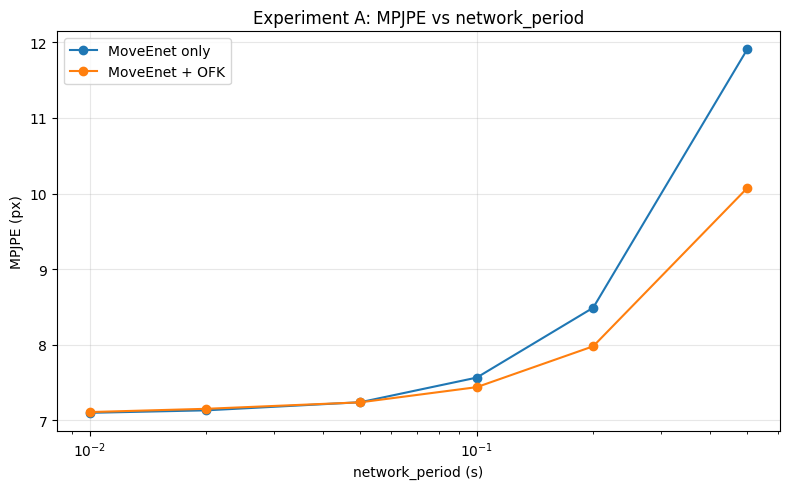

Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/plots/mpjpe_vs_network_period.png


In [8]:
plt.figure(figsize=(8, 5))
for method in ['MoveEnet only', 'MoveEnet + OFK']:
    d = df_table[df_table['method'] == method].sort_values('network_period_s')
    if len(d) == 0:
        continue
    plt.plot(d['network_period_s'], d['mpjpe_px'], marker='o', label=method)

plt.xscale('log')
plt.xlabel('network_period (s)')
plt.ylabel('MPJPE (px)')
plt.title('Experiment A: MPJPE vs network_period')
plt.grid(True, alpha=0.3)
plt.legend()
plot1 = PLOTS_DIR / 'mpjpe_vs_network_period.png'
plt.tight_layout()
plt.savefig(plot1, dpi=180)
plt.show()
print('Saved:', plot1)


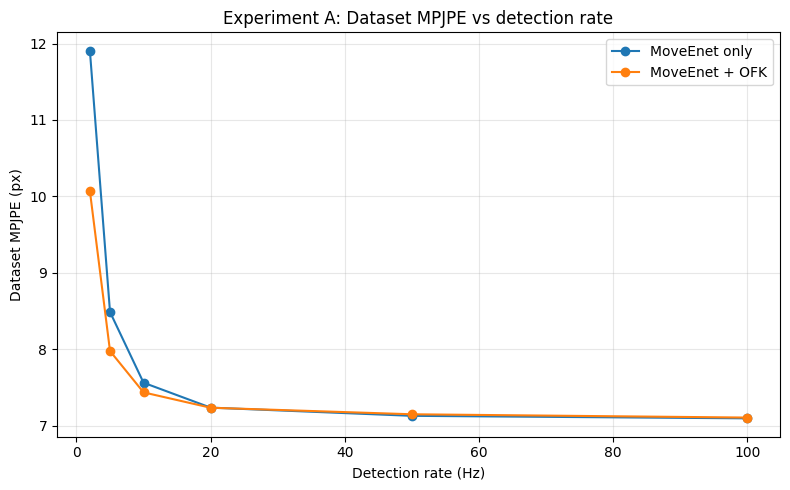

Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/plots/mpjpe_vs_detection_rate.png


In [7]:
plt.figure(figsize=(8, 5))
for method in ['MoveEnet only', 'MoveEnet + OFK']:
    d = df_table[df_table['method'] == method].sort_values('detection_rate_hz')
    if len(d) == 0:
        continue
    plt.plot(d['detection_rate_hz'], d['mpjpe_px'], marker='o', label=method)

plt.xlabel('Detection rate (Hz)')
plt.ylabel('Dataset MPJPE (px)')
plt.title('Experiment A: Dataset MPJPE vs detection rate')
plt.grid(True, alpha=0.3)
plt.legend()
plot2 = PLOTS_DIR / 'mpjpe_vs_detection_rate.png'
plt.tight_layout()
plt.savefig(plot2, dpi=180)
plt.show()
print('Saved:', plot2)
